In [1]:
import sys
sys.path.append("..")

from core.config import llm2 as llm

In [2]:
response = llm.invoke("Why did Trump attack Iran")
print("Response: ", response.content)

Response:  As of my last update in October 2023, there has been no verified report of former President Donald Trump ordering a military attack on Iran. However, tensions between the United States and Iran have been high for many years, particularly during Trump's presidency from 2017 to 2021. These tensions were often due to issues such as Iran's nuclear program, regional influence, and incidents involving military forces.

If you are referring to a specific event or development that occurred after October 2023, I would not have information on that. For the most current and accurate information, I recommend checking reliable news sources.


In [10]:
topic = {
    "name": "Git Branching",
    "notes": "Branches allow parallel develoipment of features" 
}


In [11]:
question_prompt = f"""
You are an examiner whose job is to prepare a conceptual question on a topic using the notes provided to you.
Topic: {topic["name"]}
Notes: {topic["notes"]}
"""

In [12]:
question_prompt

'\nYou are an examiner whose job is to prepare a conceptual question on a topic using the notes provided to you.\nTopic: Git Branching\nNotes: Branches allow parallel develoipment of features\n'

In [44]:
from typing import TypedDict, List
class quizState(TypedDict):
    messages: List
    quiz: {"topic": str, "notes": str, "question": str}
    user_answer: str
    understanding: str
    hint: str
    attempts: int
    

In [45]:
git_state: quizState = {
    "quiz": {"topic": topic["name"], "notes": topic["notes"], "question": ""},
    "user_answer": "",
    "hint": "",
    "understanding": "NA",
    "attempts": 0,
    "messages": [],
}

In [46]:
git_state["quiz"]

{'topic': 'Git Branching',
 'notes': 'Branches allow parallel develoipment of features',
 'question': ''}

In [59]:
def ai_gen_question(state: quizState) -> quizState:
    question_prompt = f"""
You are an examiner whose job is to prepare a conceptual question on a topic using the notes provided to you.
Topic: {state["quiz"]["topic"]}
Notes: {state["quiz"]["notes"]}
"""
    question = llm.invoke(question_prompt).content
    state["quiz"]["question"] = question
    state["messages"].append({"role": "AI", "message": question})
    return state
    

In [48]:
def ask_user(state: quizState) -> quizState:
    """
    Ask the user the AI generated quiz.
    """
    question = state["messages"][-1]["message"]
    user_reply = input(question)
    state["attempts"] += 1
    state["messages"].append({"role": "User", "message": user_reply})
    return state

In [49]:
def evaluate(state: quizState) -> bool:
    """
    Evaluate the user reply, using LLM
    """
    ai_prompt = f"""
    You have to analyze the user's reply to a quiz to check the understanding of a concept and tell whether
    it is acceptable using notes provided to you.
    Return: True or False only
    Quiz: {state["quiz"]["question"]}
    Notes: {state["quiz"]["notes"]}
    User's reply: {state["messages"][-1]["message"]}
    """
    evaluation = llm.invoke(ai_prompt).content.lower()
    return "true" in evaluation
    

In [50]:
def hints_available(state: quizState):
    """
    Return true if there are hints availbale.
    """
    return state["attempts"] <=3

In [51]:
def give_hint(state: quizState) -> quizState:
    ai_prompt = f"""
    Provide a hint to a quiz, without telling the complete answer.
    You are provided notes for generating a hint.
    quiz: {state["quiz"]["question"]}
    notes: {state["quiz"]["notes"]}
    user's reply: {state["messages"][-1]["message"]}
    """
    hint = llm.invoke(ai_prompt)
    state["messages"].append({"role": "AI", "message": hint.content})
    return state

In [60]:
from langgraph.graph import StateGraph, END

builder = StateGraph(quizState)

builder.add_node("generate_quiz", ai_gen_question)
builder.add_node("ask_user", ask_user)
builder.add_node("give_a_hint", give_hint)

builder.set_entry_point("generate_quiz")
builder.add_edge("generate_quiz", "ask_user")
builder.add_conditional_edges(
    "ask_user",
    evaluate,
    {
        True: END,
        False: "give_a_hint" if hints_available else END
    }
)
builder.add_edge("give_a_hint", "ask_user")


In [61]:
graph = builder.compile()

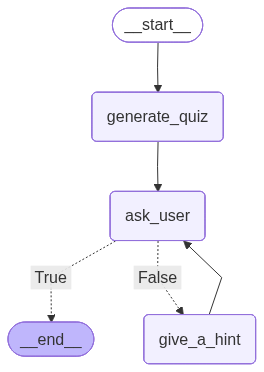

In [62]:
graph

In [63]:
workflow = graph.invoke(git_state)

Question: 

Explain the concept of branching in Git and discuss how it facilitates parallel development of features in a software project. Provide an example scenario where branching would be beneficial, and describe the steps a development team might take to effectively manage branches to ensure smooth integration of new features into the main codebase. Multiple developer can work on separate features parallely and merge their work in the main branch after review when they are done with their feature task. This helps in collaboration and integration


In [65]:
workflow

{'messages': [{'role': 'AI',
   'message': 'Question: \n\nExplain the concept of branching in Git and discuss how it facilitates parallel development of features in a software project. Provide an example scenario where branching would be beneficial, and describe the steps a development team might take to effectively manage branches to ensure smooth integration of new features into the main codebase.'},
  {'role': 'User',
   'message': 'Multiple developer can work on separate features parallely and merge their work in the main branch after review when they are done with their feature task. This helps in collaboration and integration'}],
 'quiz': {'topic': 'Git Branching',
  'notes': 'Branches allow parallel develoipment of features',
  'question': '',
  'quesion': 'Question: \n\nExplain the concept of branching in Git and discuss how it facilitates parallel development of features in a software project. Provide an example scenario where branching would be beneficial, and describe the st